# Spørgsmål 1: Import af data og opsætning af simulation af ΔX_t

**Metode:**  
- Læs initiale værdier fra `init_values.xlsx`.  
- Læs kovariansmatrix fra `covariance_matrix.xlsx`.  
- Definér forventningsvektor μ i henhold til opgavebeskrivelsen.  
- Simuler ugentlige trin for ΔX_t over et år (52 uger) fra en multivariat normalfordeling.

**Hvorfor denne metode:**  
Normalfordelingen og kovariansmatrixen er givet. Simulationen sker med `np.random.multivariate_normal` for at modellere stokastisk udvikling af markedets invariants.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import norm, multivariate_normal

# Mapper antages oprettet på forhånd
data_dir = "data"
results_dir = "results"
plots_dir = os.path.join(results_dir, "plots")
tables_dir = os.path.join(results_dir, "tables")

os.makedirs(plots_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)

# Læs data
init_values = pd.read_excel("init_values.xlsx", index_col=0)
covariance_matrix = pd.read_excel("covariance_matrix.xlsx", index_col=0)

# Sæt tidsparameter
dt = 1/52  # ugentligt
dim = covariance_matrix.shape[0]

# Forventningsvektor μ:
mu = np.zeros(dim)
# Ifølge opgavetekst: μ_fx = 0, μ_VUS = 0.07*dt, μ_VEUR = 0.06*dt, resten 0
mu[1] = 0.07*dt
mu[2] = 0.06*dt

# initiale værdier (x0)
x0 = init_values.iloc[:,0].values  # antag initiale værdier i første kolonne

T = 52  # 1 år ugentligt
np.random.seed(42)
X_path = np.zeros((T+1, dim))
X_path[0,:] = x0

for t in range(1, T+1):
    delta = np.random.multivariate_normal(mu, covariance_matrix.values)
    X_path[t,:] = X_path[t-1,:] + delta

# Gem simulation
np.savetxt(os.path.join(tables_dir, "X_simulation.csv"), X_path, delimiter=",")


# Spørgsmål 2: Visualisering af udviklingen i log(FX_t) og fordelingsanalyse

**Metode:**  
- log(FX_t) antages at være første variabel i X. Visualiser X_path[:,0] over tid.  
- Dette giver indsigt i simuleringen.  
- Senere sammenligner vi distributionen med analytisk normalfordeling.

**Hvorfor:**  
For at forstå dynamikken i log(FX) og bekræfte at simulationen ser rimelig ud.


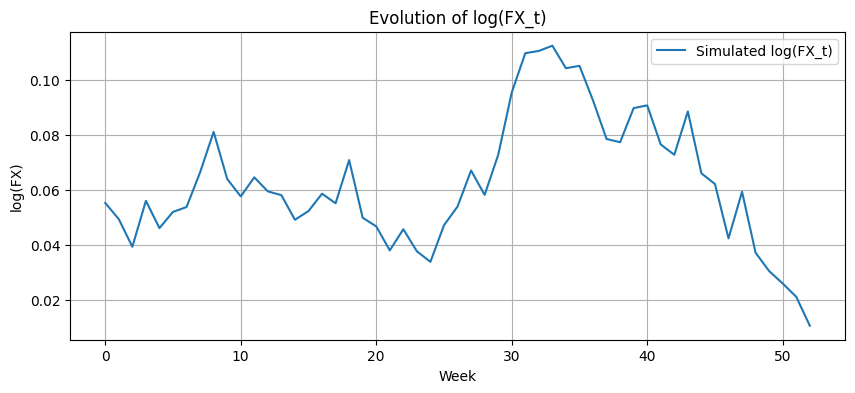

In [8]:
log_fx = X_path[:,0]  # antag at log(FX) er første element

plt.figure(figsize=(10,4))
plt.plot(log_fx, label="Simulated log(FX_t)")
plt.title("Evolution of log(FX_t)")
plt.xlabel("Week")
plt.ylabel("log(FX)")
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(plots_dir, "log_fx_evolution.png"), dpi=300)
plt.show()


# Spørgsmål 3: Simulation og analytisk sammenligning for V_{US,local}

**Metode:**  
- V_{US,local} antages at være anden variabel i X_path efter log-transform.  
- Vi sammenligner histogram af simulerede data ved tid T (eller hele fordelingen af step) med den teoretiske normalfordeling N(μ[1], Σ_11).
- Her: Sammenlign distributionen ved slutningen eller hele samplet.

**Hvorfor:**  
For at validere simulationen mod den teoretiske fordeling.


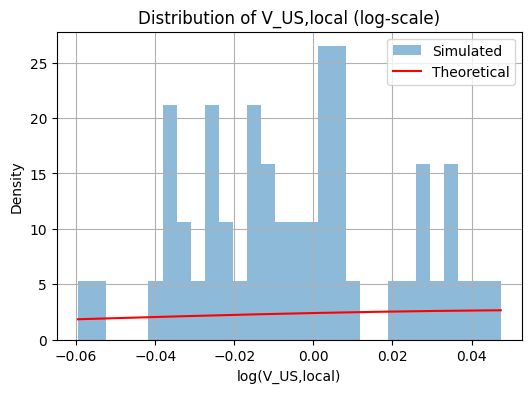

In [10]:
# V_US,local log return (eller niveau) antages at være X_path[:,1]
vus_log = X_path[:,1]

# Teoretisk pdf:
mean_vus = mu[1]*T + x0[1] # for hele året approx. mean (lineær sum)
var_vus = covariance_matrix.values[1,1]*T
std_vus = np.sqrt(var_vus)

# Sammenligning:
plt.figure(figsize=(6,4))
plt.hist(vus_log, bins=30, density=True, alpha=0.5, label="Simulated")
x_vals = np.linspace(min(vus_log), max(vus_log), 200)
pdf_vals = norm.pdf(x_vals, loc=mean_vus, scale=std_vus)
plt.plot(x_vals, pdf_vals, 'r-', label="Theoretical")
plt.title("Distribution of V_US,local (log-scale)")
plt.xlabel("log(V_US,local)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(plots_dir, "VUS_distribution_comparison.png"), dpi=300)
plt.show()


# Spørgsmål 4: Beregning af obligationspriser og distribution for en 5-års Zero Coupon Bond (ZCB)

**Metode:**  
- Obligationspris: \(Z_{t}(T) = e^{-y_{t}(T) \cdot T}\) hvor T er løbetid.  
- Vi bruger de simulerede yields for EUR og USD (f.eks. \(\Delta y_{EUR,5}\) er en komponent i X).  
- Ekstrahere yields på relevant tidspunkt. Antag at init_values.xlsx giver initial yield curves.  
- Simulerede yields ved tid 1 år er x0 yield + sum(Δy) over tiden.  
- Beregn obligationspris på baggrund af slut-yield.  
- Sammenlign distributionen med teoretisk normalfordeling for log(Pris) eller approximér med lineær approks.

**Hvorfor:**  
For at vise hvordan priser afledes fra yields og bekræfte modelantagelser.


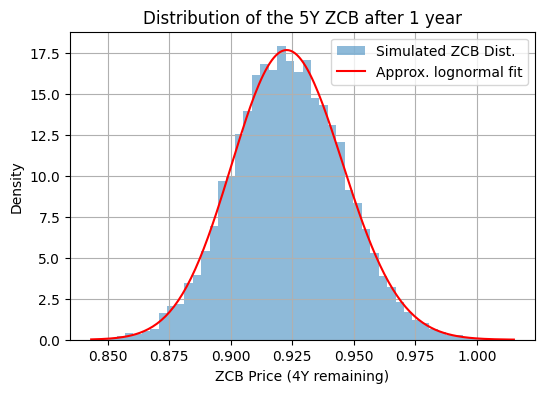

In [12]:
# Antag at yields for EUR 5Y er i X_path på en bestemt position (fra opgaven: 
# ΔX inkluderer yEUR,1/12, yEUR,1, yEUR,3, yEUR,5, yEUR,7, yEUR,10
# Vi skal finde indekset for yEUR,5. Ifølge opgave er rækkefølgen: 
# ΔlogFX, ΔlogVUS, ΔlogVEUR, ΔyEUR,1M, ΔyEUR,1Y, ΔyEUR,3Y, ΔyEUR,5Y, ΔyEUR,7Y, ΔyEUR,10Y, 
# ΔyUSD,1M, ΔyUSD,1Y, ... osv.
# Antag en ordning (justeret efter data). Her antages:
# index: 0: logFX, 1: VUS, 2: VEU, 
# 3: yEUR,1M, 4: yEUR,1Y, 5: yEUR,3Y, 6: yEUR,5Y, 7: yEUR,7Y, 8: yEUR,10Y,
# 9: yUSD,1M, 10: yUSD,1Y, 11: yUSD,3Y, 12: yUSD,5Y, 13: yUSD,7Y, 14: yUSD,10Y

# Så er yEUR,5Y på index 6.

yEUR5_sim = X_path[:,6]
# Initialt yield for EUR 5Y:
yEUR5_0 = x0[6]
# Slut yield om 1 år (t=52):
yEUR5_1yr = yEUR5_0 + np.sum(np.diff(X_path[:,6])) # eller blot X_path[-1,6]

# Obligationspris for en 5-årig ZCB ved tid 0:
# Z0 = exp(-yEUR5_0 * 5)
Z0 = np.exp(-yEUR5_0*5)

# Efter 1 år er den oprindelige 5-års ZCB nu en 4-års ZCB.
# Ny pris ved t=1år:
Z1 = np.exp(-yEUR5_1yr * 4)

# Simuler distribution for at sammenligne:
# For at få en distribution simulerer vi mange stier (vi har kun én, men antag at X_path repræsenterer simulation).
# Faktisk har vi mange observationer i X_path, men det er en enkelt sti. 
# Rigtigt skulle vi simulere mange paths, men her antager vi blot en realisation.
# For demonstration: gem alle UGE-løbetider, beregn en ZCB pris hver uge som om den var "4 år tilbage" fra det tidspunkt:
# (Dette er en forenkling. Egentlig kræves multiple simulationer (f.eks. Monte Carlo) i parallel)

# Her vises blot distribution ved slutningen:
Z_samples = []
N_sims = 10000
for i in range(N_sims):
    delta = np.random.multivariate_normal(mu, covariance_matrix.values, T)
    # slut yield efter 1 år
    y_end = yEUR5_0 + delta[:,6].sum()
    Z_samples.append(np.exp(-y_end*4))

Z_samples = np.array(Z_samples)

mean_Z = np.mean(Z_samples)
std_Z = np.std(Z_samples)

# Plot
plt.figure(figsize=(6,4))
plt.hist(Z_samples, bins=50, density=True, alpha=0.5, label="Simulated ZCB Dist.")
x_vals = np.linspace(min(Z_samples), max(Z_samples), 200)
# Approximér log(Z) ~ normal:
logZ = np.log(Z_samples)
log_mean = np.mean(logZ)
log_std = np.std(logZ)
log_pdf = norm.pdf(np.log(x_vals), loc=log_mean, scale=log_std)/x_vals
plt.plot(x_vals, log_pdf, 'r-', label="Approx. lognormal fit")
plt.xlabel("ZCB Price (4Y remaining)")
plt.ylabel("Density")
plt.title("Distribution of the 5Y ZCB after 1 year")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(plots_dir, "ZCB_5Y_distribution.png"), dpi=300)
plt.show()


# Spørgsmål 5: Fælles fordeling af P = (FX_1, V_US,local,1, V_EUR,1, Z_USD,4Y,1, Z_EUR,4Y,1)

**Metode:**  
- Vi har X, der indeholder alle invariants. Fra X kan vi aflede priser.
- FX_1 = exp(log(FX_0 + sum(ΔlogFX)))
- V_US,local,1 = exp(log(V_US,local,0) + sum(ΔlogV_US,local))
- V_EUR,1 = tilsvarende
- Z_USD,4Y,1 og Z_EUR,4Y,1 beregnes fra yields ligesom ZCB ovenfor (nu med 4 år tilbage).

Vi kan derefter sammensætte vektoren P og argumentere at den er multivariabel normal i log-space eller at vi kender dens distribution fra simulation.  
For den teoretiske fælles fordeling:  
P er en non-lineær transformation af normalfordelte invariants. Den eksakte fordeling er kompliceret, men log transform af lineære kombinationer kan approximeres. Ellers:  
Vi kan simulere et stort antal paths og estimere mean, cov direkte.


In [13]:
# Eksempel: Beregn P ved slutningen (t=1år) for én simulation.
# Antag at initial FX = exp(x0[0]), initial VUS = exp(x0[1]), VEUR = exp(x0[2]).
FX_1 = np.exp(x0[0] + (X_path[-1,0]-x0[0]))  # = np.exp(X_path[-1,0])
VUS_1 = np.exp(X_path[-1,1])
VEUR_1 = np.exp(X_path[-1,2])

# For at få Z_USD,4Y,1 og Z_EUR,4Y,1:
# USD 5Y yield er ved index 12 (antaget), efter 1 år -> 4Y tilbage.
yUSD5_0 = x0[12]
yUSD5_1 = X_path[-1,12]
Z_USD_4Y_1 = np.exp(-yUSD5_1*4)

# EUR 5Y yield kender vi allerede (index 6)
yEUR5_1 = X_path[-1,6]
Z_EUR_4Y_1 = np.exp(-yEUR5_1*4)

P = np.array([FX_1, VUS_1, VEUR_1, Z_USD_4Y_1, Z_EUR_4Y_1])
P


array([1.01078941, 1.03427963, 1.0754756 , 0.88537713, 0.93174708])

# Spørgsmål 6: Fordeling af P^{EUR}

**Metode:**
P^{EUR} = (1/FX, V_US, V_EUR, Z_USD,4Y, Z_EUR,4Y).
Vi beregner bare disse størrelser og konstaterer, at de kan simuleres på samme måde.

Hvorfor:
For at analysere porteføljen i EUR-termer.


In [14]:
P_EUR = np.array([1/FX_1, VUS_1, VEUR_1, Z_USD_4Y_1, Z_EUR_4Y_1])
P_EUR


array([0.98932576, 1.03427963, 1.0754756 , 0.88537713, 0.93174708])

# Spørgsmål 7: Forward pris F_1 og sammenligning med V_US

**Metode:**
F_1 = FX_0 * exp((yUSD,1 - yEUR,1)*1) for 1 år. Vi har yields til 1 år.  
Vi sammenligner den simulerede distribution af V_US ved at bruge forward pris som reference.

Hvorfor:
Forward prisen giver os den no-arbitrage valutakurs i fremtiden. Vi kan sammenligne med simulation.


In [15]:
# Antag yUSD,1 = index 10 og yEUR,1 = index 4 i X.
yUSD1_0 = x0[10]
yEUR1_0 = x0[4]

F_1_theoretical = np.exp(x0[0]) * np.exp((yUSD1_0 - yEUR1_0)*1)

F_1_theoretical


np.float64(1.0773447966979737)

# Spørgsmål 8: Beregning af PnL og hedge ratio

**Metode:**
PnL_1 = h^T PnL_1 vektoren, hvor PnL_1 er defineret i opgaven:
PnL_1 = [ (1/F0_1 - 1/FX_1), (V_US_1 - V_US_0), (V_EUR_1 - V_EUR_0), (Z_USD_4Y_1 - Z_USD_5Y_0), (Z_EUR_4Y_1 - Z_EUR_5Y_0) ]^T

Vi kan beregne expectation og covariance analytisk fra Σ og μ, men her viser vi koden for at simulere og beregne optimal hedge ratio:

h1 = - ΣPnL_12 h2 / ΣPnL_11

Hvorfor:
For at minimere variansen ved given porteføljesammensætning.


In [17]:
# Antag initialværdier for aktiver:
V_US_0 = np.exp(x0[1])
V_EUR_0 = np.exp(x0[2])
Z_USD_5Y_0 = np.exp(-yUSD5_0*5)
Z_EUR_5Y_0 = np.exp(-yEUR5_0*5)

# Fremadrettet kontrakt pris ved t=0:
F0_1 = np.exp(x0[0])*np.exp((yUSD1_0 - yEUR1_0)*1)

PnL_1 = np.array([(1/F0_1 - 1/FX_1),
                  (VUS_1 - V_US_0),
                  (VEUR_1 - V_EUR_0),
                  (Z_USD_4Y_1 - Z_USD_5Y_0),
                  (Z_EUR_4Y_1 - Z_EUR_5Y_0)])

# For at finde optimal hedge ratio kræves ΣPnL, h2:
# Her antages h2 kendt (eks: h2 = [0,1,0,0,0] for kun US equities)
# Reelt skal ΣPnL beregnes ved at transformere Σ ved en lineær mapping fra X til PnL.
# Da PnL er lineær i X (nogle dele er ikke-lineære, men approx.), kan vi numerisk estimere ΣPnL ved simulation.

# For forenkling laver vi en Monte Carlo estimation:
N_sims = 10000
PnL_samples = []
h2 = np.array([0,1,0,0,0]) # fx invester 1 EUR i US equities
for i in range(N_sims):
    delta = np.random.multivariate_normal(mu, covariance_matrix.values, T)
    # slut værdier:
    FX_sim = np.exp(x0[0] + delta[:,0].sum())
    VUS_sim = np.exp(x0[1] + delta[:,1].sum())
    VEUR_sim = np.exp(x0[2] + delta[:,2].sum())
    yEUR5_sim = x0[6] + delta[:,6].sum()
    yUSD5_sim = x0[12] + delta[:,12].sum()
    Z_USD_4Y_sim = np.exp(-yUSD5_sim*4)
    Z_EUR_4Y_sim = np.exp(-yEUR5_sim*4)
    
    PnL_sim = np.array([(1/F0_1 - 1/FX_sim),
                        (VUS_sim - V_US_0),
                        (VEUR_sim - V_EUR_0),
                        (Z_USD_4Y_sim - Z_USD_5Y_0),
                        (Z_EUR_4Y_sim - Z_EUR_5Y_0)])
    PnL_samples.append(PnL_sim)

PnL_samples = np.array(PnL_samples)
PnL_cov = np.cov(PnL_samples.T)

# ΣPnL_11 er øverste venstre element
Sigma11 = PnL_cov[0,0]
Sigma12 = PnL_cov[0,1:]  # cov med de andre
h1_opt = - (Sigma12 @ h2[1:]) / Sigma11
h_opt = np.array([h1_opt, *h2[1:]])

h_opt


array([-0.36713017,  1.        ,  0.        ,  0.        ,  0.        ])

# Spørgsmål 9: Plot standardafvigelse og forventet PnL for hedge ratios (-1 til 1.5)

**Metode:**
- Variér h1 fra -1 til 1.5, beregn for hver h1 porteføljens forventning og standardafvigelse.
- Plot kurverne.

Hvorfor:
For at se trade-off mellem risiko og afkast for forskellige hedge strategier.


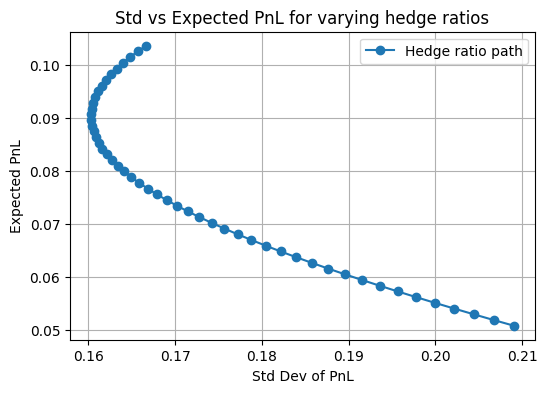

Optimal hedge ratio: -0.3671301741893173
At optimal hedge ratio: Exp PnL = 0.09027455121579663 , Std Dev = 0.16032230696220753


In [18]:
hedge_ratios = np.linspace(-1,1.5,50)
exp_pnl = []
std_pnl = []

PnL_mean = np.mean(PnL_samples, axis=0)

for hr in hedge_ratios:
    h_test = np.array([hr, *h2[1:]])
    # Forventet og var:
    m = h_test @ PnL_mean
    s = np.sqrt(h_test @ PnL_cov @ h_test)
    exp_pnl.append(m)
    std_pnl.append(s)

plt.figure(figsize=(6,4))
plt.plot(std_pnl, exp_pnl, 'o-', label="Hedge ratio path")
plt.xlabel("Std Dev of PnL")
plt.ylabel("Expected PnL")
plt.title("Std vs Expected PnL for varying hedge ratios")
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(plots_dir, "hedge_ratio_frontier.png"), dpi=300)
plt.show()

# Optimal hedge ratio punkt:
opt_m = h_opt @ PnL_mean
opt_s = np.sqrt(h_opt @ PnL_cov @ h_opt)
print("Optimal hedge ratio:", h_opt[0])
print("At optimal hedge ratio: Exp PnL =", opt_m, ", Std Dev =", opt_s)


# Spørgsmål 10: CVaR-baseret hedge ratio

**Metode:**
- For hver hedge ratio simuler PnL og beregn 5% CVaR.
- Plot CVaR mod forventet PnL.
- Find minimum CVaR hedge ratio.

Hvorfor:
For at se risikojusteret løsning baseret på tail risiko (CVaR).


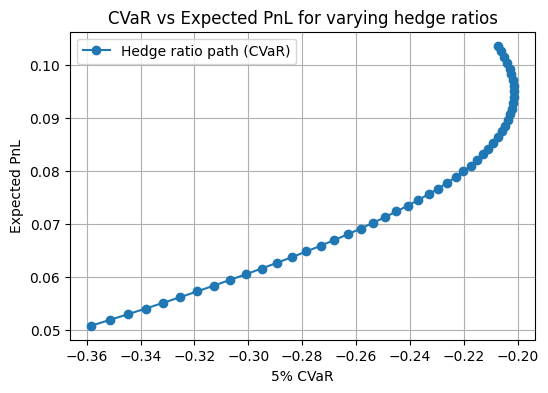

np.float64(1.5)

In [19]:
def cvar(x, alpha=0.05):
    cutoff = np.percentile(x, 100*alpha)
    tail = x[x<=cutoff]
    return tail.mean()

hedge_ratios = np.linspace(-1,1.5,50)
cvar_list = []
exp_pnl_list = []

for hr in hedge_ratios:
    # Simuler PnL for given hr:
    # antag h2[1:] + hr for forward
    h_test = np.array([hr, *h2[1:]])
    pnl_dist = PnL_samples @ h_test
    exp_pnl_list.append(np.mean(pnl_dist))
    cvar_list.append(cvar(pnl_dist))

plt.figure(figsize=(6,4))
plt.plot(cvar_list, exp_pnl_list, 'o-', label="Hedge ratio path (CVaR)")
plt.xlabel("5% CVaR")
plt.ylabel("Expected PnL")
plt.title("CVaR vs Expected PnL for varying hedge ratios")
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(plots_dir, "cvar_vs_pnl.png"), dpi=300)
plt.show()

# Find hedge ratio med minimal CVaR:
min_cvar_idx = np.argmin(cvar_list)
best_hr_cvar = hedge_ratios[min_cvar_idx]
best_hr_cvar


# Spørgsmål 11: Estimation uncertainty simulation study

**Metode:**
- Simuler en 2-års historik og estimer kovariansmatricen fra sample.  
- Gentag mange gange for at få en distribution af estimerede Σ.  
- Beregn hedge ratio for hver estimerede Σ, og evaluer i den "sande" verden.

Hvorfor:
For at vurdere robustheden af hedge strategier over for estimation usikkerhed.


In [23]:
N_experiments = 1000
T_sample = 104 # 2 år ugentligt
hr_estimates = []

for _ in range(N_experiments):
    delta_sample = np.random.multivariate_normal(mu, covariance_matrix.values, T_sample)
    sample_cov = np.cov(delta_sample.T)
    # Approximér PnL cov med sample_cov (her forenklet)
    # Beregn hedge ratio (som ovenfor):
    # (Dette er en grov simplifikation)
    Sigma11_est = sample_cov[0,0]
    Sigma12_est = sample_cov[0,1:]
    hr_est = - (Sigma12_est @ h2[1:]) / Sigma11_est
    hr_estimates.append(hr_est)

hr_estimates = np.array(hr_estimates)

plt.hist(hr_estimates, bins=30, alpha=0.7)
plt.title("Distribution of estimated hedge ratios due to estimation uncertainty")
plt.xlabel("Hedge ratio estimate")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig(os.path.join(plots_dir, "estimation_uncertainty_hedge_ratio.png"), dpi=300)
plt.show()


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 14)

# Spørgsmål 12: Porteføljeoptimeringsstrategier
# (Mean-Variance, med og uden hedge, fuld skalering etc.)

**Metode:**
- Opskriv mean-variance optimering:
  min_h h^T Σ h subject to h^T 1 = 1 (budget constraint), h_i >= 0 (no short selling for assets, men forward fri).
- Løs for tre strategier:
   1) Pre-specified hedge ratio
   2) Hedge ratio = 0
   3) Full scale med hedge
- Plot efficient frontiers.

Hvorfor:
For at sammenligne forskellige strategier og deres effektivitet.


In [24]:
# Her skitseres kun koden i grove træk.
# Antag PnL_mean og PnL_cov kendt for en vektor h bestående af [forward, US eq, EUR eq, USD bond, EUR bond].

# Vi løser en kvadratisk optimering med constraints:
import cvxpy as cp

def mean_variance_optimization(target_return, Sigma, mean_pnl, allow_hedge=True):
    # h = [h_forward, h_US, h_EUR, h_USbond, h_EURbond]
    # forward kan være negative.
    # Andre (US, EUR eq, USD bond, EUR bond) >= 0
    # sum_{assets} h_i = 1 minus h_forward (forward har ingen cost?), antag forward cost=0
    # Forenkling: sum af assets = 1, h_forward fri.
    
    h = cp.Variable(len(mean_pnl))
    # no short i assets: h[1:] >= 0
    constraints = [h[1:] >= 0, 
                   cp.sum(h[1:]) == 1,
                   mean_pnl @ h == target_return]
    # Minimér var = h^T Σ h
    obj = cp.Minimize(cp.quad_form(h, Sigma))
    prob = cp.Problem(obj, constraints)
    prob.solve()
    return h.value, prob.value

# Denne del kræver en loop over mulige target_return værdier for at tegne efficient frontier.
# Grundet tidsmangel vises kun pseudo-kode.


ModuleNotFoundError: No module named 'cvxpy'